### All of Statistics | Larry Wasserman | Solutions and Code by David A. Lee
### Chapter 7: Estimating the CDF and Statistical Functionals

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm, cauchy
import matplotlib.pyplot as plt
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\math")
from plotstyle import C, FG, BG, savefig, animation_style, saveanim, neon_cmap
SEED = 2024   # each cell starts its own generator from this, so every figure is reproducible on its own

3. (Computer Experiment.) Generate 100 observations from a $N(0, 1)$ distribution. Compute a 95 percent confidence band for the CDF $F$. Repeat this 1000 times and see how often the confidence band contains the true distribution function. Repeat using data from a Cauchy distribution.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap7ex3i.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap7\chap7ex3i.eps


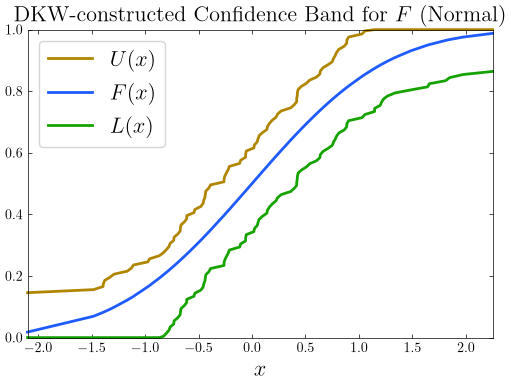

In [2]:
# Dvoretzky-Kiefer-Wolfowitz confidence interval construction for Normal distribution
rng = np.random.default_rng(SEED)

n = 100
alpha = 0.05
eps = np.sqrt((1/(2*n))*np.log(2/alpha))

def ecdfhat(sample):
    return np.arange(1, len(sample)+1)/len(sample)

def dkwintnormal():
    sample = np.sort(rng.normal(0, 1, n))
    ecdf = ecdfhat(sample)
    lowerbound = np.maximum(ecdf - eps, 0)
    upperbound = np.minimum(ecdf + eps, 1)
    dkwtest = (norm.cdf(sample) >= lowerbound) & (norm.cdf(sample) <= upperbound)
    return dkwtest, lowerbound, upperbound, ecdf, sample;

# Plot variables

dkwtest, lower_plot, upper_plot, ecdf_plot, sample_plot = dkwintnormal()
truecdf_plot = norm.cdf(sample_plot)

plt.figure(figsize=(6,4))
plt.plot(sample_plot, upper_plot, linewidth=2, color=C.yellow, clip_on=False, label='$U(x)$')
plt.plot(sample_plot, truecdf_plot, linewidth=2, color=C.blue, clip_on=False, label='$F(x)$')
plt.plot(sample_plot, lower_plot, linewidth=2, color=C.green, clip_on=False, label='$L(x)$')
plt.title('DKW-constructed Confidence Band for $F$ (Normal)', fontsize=16)
plt.xlabel('$x$', fontsize=16)
plt.xlim([sample_plot.min(), sample_plot.max()])
plt.ylim([0,1])
plt.minorticks_off()
plt.legend(loc= 'upper left', frameon=True, fontsize=16)

savefig(plt.gcf(), 'chap7ex3i.eps', bbox_inches=None)
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_12176\782651380.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(list(range(1,m+1)), plotconfbandnormal(m), linewidth=2, color=C.blue, clip_on=False, label='$\mathbb{P} \left( L(x) \le F(x) \le U(x) \\forall x \\right)$')
C:\Users\david\AppData\Local\Temp\ipykernel_12176\782651380.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.title('$\mathbb{{P}} \left( L(x) \le F(x) \le U(x) \\right)$ ({} iterations, Normal)'.format(m), fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap7ex3ii.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap7\chap7ex3ii.eps


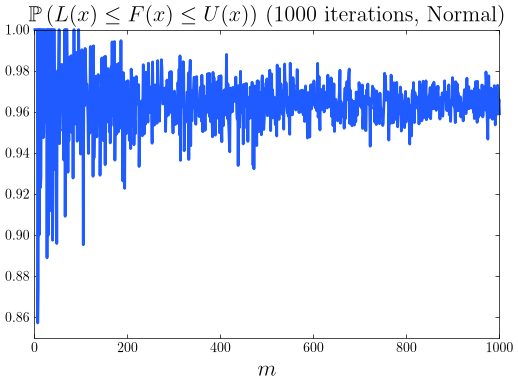

In [3]:
rng = np.random.default_rng(SEED)

n = 100
alpha = 0.05
eps = np.sqrt((1/(2*n))*np.log(2/alpha))

def ecdfhat(sample):
    return np.arange(1, len(sample)+1)/len(sample)

def confbandnormal(k): # fraction of k independent bands (n draws each) that contain F at every sample point
    samples = np.sort(rng.normal(0, 1, size=(k, n)), axis=1)
    ecdf = ecdfhat(samples[0])   # the ECDF at the i-th order statistic is i/n in every row
    lower, upper = np.maximum(ecdf - eps, 0), np.minimum(ecdf + eps, 1)
    F = norm.cdf(samples)
    return np.count_nonzero(np.all((F >= lower) & (F <= upper), axis=1)) / k;

def plotconfbandnormal(m):
    return np.array([confbandnormal(i) for i in range(1, m+1)])

m = 1000

plt.figure(figsize=(6,4))
plt.plot(list(range(1,m+1)), plotconfbandnormal(m), linewidth=2, color=C.blue, clip_on=False, label='$\mathbb{P} \left( L(x) \le F(x) \le U(x) \\forall x \\right)$')
plt.title('$\mathbb{{P}} \left( L(x) \le F(x) \le U(x) \\right)$ ({} iterations, Normal)'.format(m), fontsize=16)
plt.xlabel('$m$', fontsize=16)
plt.xlim([0, m])
plt.ylim([0.85,1])
plt.minorticks_off()

savefig(plt.gcf(), 'chap7ex3ii.eps', bbox_inches=None)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap7ex3iii.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap7\chap7ex3iii.eps


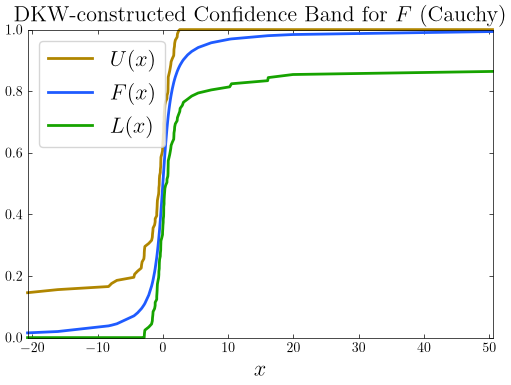

In [4]:
# Dvoretzky-Kiefer-Wolfowitz confidence interval construction for Cauchy distribution
rng = np.random.default_rng(SEED)

n = 100
alpha = 0.05
eps = np.sqrt((1/(2*n))*np.log(2/alpha))

def ecdfhat(sample):
    return np.arange(1, len(sample)+1)/len(sample)

def dkwintcauchy():
    sample = np.sort(rng.standard_cauchy(n))
    ecdf = ecdfhat(sample)
    lowerbound = np.maximum(ecdf - eps, 0)
    upperbound = np.minimum(ecdf + eps, 1)
    dkwtest = (cauchy.cdf(sample) >= lowerbound) & (cauchy.cdf(sample) <= upperbound)
    return dkwtest, lowerbound, upperbound, ecdf, sample;

# Plot variables

dkwtest, lower_plot, upper_plot, ecdf_plot, sample_plot = dkwintcauchy()
truecdf_plot = cauchy.cdf(sample_plot)

plt.figure(figsize=(6,4))
plt.plot(sample_plot, upper_plot, linewidth=2, color=C.yellow, clip_on=False, label='$U(x)$')
plt.plot(sample_plot, truecdf_plot, linewidth=2, color=C.blue, clip_on=False, label='$F(x)$')
plt.plot(sample_plot, lower_plot, linewidth=2, color=C.green, clip_on=False, label='$L(x)$')
plt.title('DKW-constructed Confidence Band for $F$ (Cauchy)', fontsize=16)
plt.xlabel('$x$', fontsize=16)
plt.xlim([sample_plot.min(), sample_plot.max()])
plt.ylim([0,1])
plt.minorticks_off()
plt.legend(loc= 'upper left', frameon=True, fontsize=16)

savefig(plt.gcf(), 'chap7ex3iii.eps', bbox_inches=None)
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_12176\451509363.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(list(range(1,m+1)), plotconfbandcauchy(m), linewidth=2, color=C.blue, clip_on=False, label='$\mathbb{P} \left( L(x) \le F(x) \le U(x) \\forall x \\right)$')
C:\Users\david\AppData\Local\Temp\ipykernel_12176\451509363.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.title('$\mathbb{{P}} \left( L(x) \le F(x) \le U(x) \\right)$ ({} iterations, Cauchy)'.format(m), fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap7ex3iv.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap7\chap7ex3iv.eps


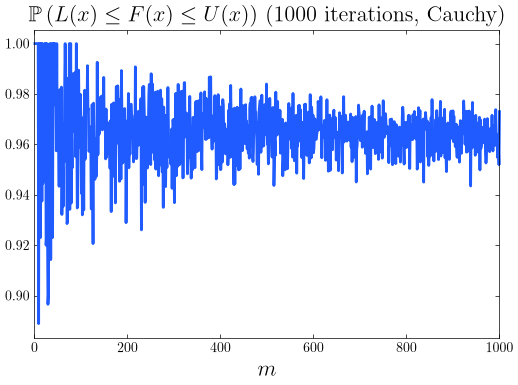

In [5]:
rng = np.random.default_rng(SEED)

n = 100
alpha = 0.05
eps = np.sqrt((1/(2*n))*np.log(2/alpha))

def ecdfhat(sample):
    return np.arange(1, len(sample)+1)/len(sample)

def confbandcauchy(k): # fraction of k independent bands (n draws each) that contain F at every sample point
    samples = np.sort(rng.standard_cauchy(size=(k, n)), axis=1)
    ecdf = ecdfhat(samples[0])   # the ECDF at the i-th order statistic is i/n in every row
    lower, upper = np.maximum(ecdf - eps, 0), np.minimum(ecdf + eps, 1)
    F = cauchy.cdf(samples)
    return np.count_nonzero(np.all((F >= lower) & (F <= upper), axis=1)) / k;

def plotconfbandcauchy(m):
    return np.array([confbandcauchy(i) for i in range(1, m+1)])

m = 1000

plt.figure(figsize=(6,4))
plt.plot(list(range(1,m+1)), plotconfbandcauchy(m), linewidth=2, color=C.blue, clip_on=False, label='$\mathbb{P} \left( L(x) \le F(x) \le U(x) \\forall x \\right)$')
plt.title('$\mathbb{{P}} \left( L(x) \le F(x) \le U(x) \\right)$ ({} iterations, Cauchy)'.format(m), fontsize=16)
plt.xlabel('$m$', fontsize=16)
plt.xlim([0, m])
#plt.ylim([0.85,1])
plt.minorticks_off()

savefig(plt.gcf(), 'chap7ex3iv.eps', bbox_inches=None)
plt.show()


7. Data on the magnitudes of earthquakes near Fiji are available on the website for this book. Estimate the CDF $F(x)$. Compute and plot a 95 percent confidence envelope for $F$. Find an approximate 95 percent confidence interval for $F(4.9) − F(4.3)$.

<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
C:\Users\david\AppData\Local\Temp\ipykernel_12176\434669102.py:39: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(magdata, fhat, linestyle='solid', linewidth=2, color=C.orange, clip_on=False, label='$\hat{F}_n(x)$')


The 95 percent confidence interval for F(4.9) - F(4.3) is (np.float64(0.49505160620646044), np.float64(0.5569483937935397))


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap7ex7.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap7\chap7ex7.eps


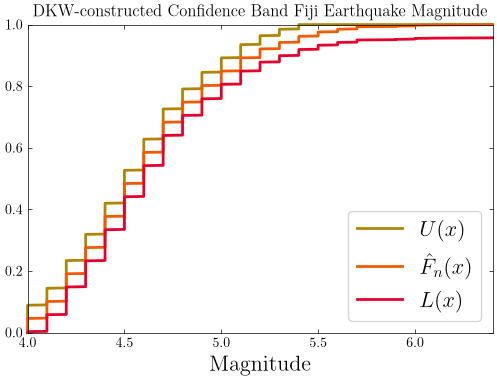

In [6]:
fijidata = pd.read_csv('fijiquakes.dat', sep=r'\s+')
    
magdata = np.sort(fijidata['mag'])

n = len(magdata)
alpha = 0.05
eps = np.sqrt((1/(2*n))*np.log(2/alpha))

def ecdfhat(sample):
    cdfhat = [ i/len(sample) for i in range(1, len(sample)+1)]
    return cdfhat;

def dkwbounds():
    lowerbound, upperbound = np.empty(len(magdata)), np.empty(len(magdata))
    ecdf = ecdfhat(magdata)
    for i in range(0, len(magdata)):
        lowerbound[i] = max(ecdf[i] - eps, 0)
        upperbound[i] = min(ecdf[i] + eps, 1)
    return lowerbound, upperbound;

# Plot variables

fhat = ecdfhat(magdata)
lower_plot = dkwbounds()[0]
upper_plot = dkwbounds()[1]

# Use results of exercise 7.4.6 for confidence interval

def ecdf(x): # empirical CDF of the magnitudes: fraction of observations <= x
    return np.mean(magdata <= x)


theta = ecdf(4.9) - ecdf(4.3)
sehat = np.sqrt((1/len(magdata))*theta*(1-theta))
print('The 95 percent confidence interval for F(4.9) - F(4.3) is',(theta - 1.96*sehat, theta + 1.96*sehat))

plt.figure(figsize=(6,4))
plt.plot(magdata, upper_plot, linestyle='solid', linewidth=2, color=C.yellow, clip_on=False, label='$U(x)$')
plt.plot(magdata, fhat, linestyle='solid', linewidth=2, color=C.orange, clip_on=False, label='$\hat{F}_n(x)$')
plt.plot(magdata, lower_plot, linestyle='solid', linewidth=2, color=C.red, clip_on=False, label='$L(x)$')
plt.title('DKW-constructed Confidence Band Fiji Earthquake Magnitude', fontsize=12)
plt.xlabel('Magnitude', fontsize=16)
plt.xlim([magdata.min(), magdata.max()])
plt.ylim([0,1])
plt.minorticks_off()
plt.legend(loc= 'lower right', frameon=True, fontsize=16)

savefig(plt.gcf(), 'chap7ex7.eps', bbox_inches=None)
plt.show()

8. Get the data on eruption times and waiting times between eruptions of the Old Faithful geyser from the website. Estimate the mean waiting time and give a standard error for the estimate. Also, give a 90 percent confidence interval for the mean waiting time. Now estimate the median waiting time. In the next chapter we will see how to get the standard error for the median.

In [7]:
faithful = pd.read_csv('faithful.dat', sep=r'\s+')
    
waitingdata = faithful['waiting']

waitingmean = np.mean(waitingdata)
waitingse = np.std(waitingdata, ddof=1) / np.sqrt(np.size(waitingdata))

waitingci = (round(waitingmean - 1.65*waitingse, 3), round(waitingmean + 1.65*waitingse, 3))

waitingmedian = np.median(waitingdata)

print(round(waitingmean, 3), round(waitingse, 3), waitingci, round(waitingmedian, 3))


70.897 0.824 (np.float64(69.537), np.float64(72.257)) 76.0


10. In 1975, an experiment was conducted to see if cloud seeding produced rainfall. 26 clouds were seeded with silver nitrate and 26 were not. The decision to seed or not was made at random. Let $\theta$ be the difference in the mean precipitation from the two groups. Estimate $\theta$. Estimate the standard error of the estimate and produce a 95 percent confidence interval.

In [8]:
clouds = pd.read_csv('clouds.dat', sep=r'\s+')

unseeded = clouds['Unseeded_Clouds']
seeded = clouds['Seeded_Clouds']

diffmean = np.abs(np.mean(unseeded) - np.mean(seeded))
unseeded_se = np.std(unseeded, ddof=1) / np.sqrt(np.size(unseeded))
seeded_se = np.std(seeded, ddof=1) / np.sqrt(np.size(seeded))
diffse = np.sqrt(np.square(unseeded_se) + np.square(seeded_se))

diffci = (round(diffmean - 1.96*diffse, 3), round(diffmean + 1.96*diffse, 3))

print(round(diffmean, 3), round(diffse, 3), diffci)



277.396 138.82 (np.float64(5.309), np.float64(549.483))
